# 🩺 Silent Risk — Predicting Chronic Disease Before It Strikes

---

> **Context:** A national health insurer wants to identify high-risk members before they develop costly chronic conditions. This project leverages the CDC BRFSS 2024 survey (~400k respondents) to predict diabetes risk and multi-morbidity, and to map prevention priorities geographically.

---

## Section 0 — Introduction & Business Context

---

### Section 0.1 — Project Pitch

#### The Problem

Health insurers operate in a fundamentally reactive model: claims arrive, costs are absorbed, and interventions come too late. Chronic diseases — diabetes, heart disease, depression, COPD — develop silently over years before they surface as expensive medical events.

#### The Opportunity

The CDC BRFSS survey captures exactly the behavioral and demographic signals that precede chronic disease: smoking habits, physical inactivity, income stress, lack of healthcare access. These signals are observable **before** diagnosis.

#### The Solution

A predictive risk engine that:
- Scores individuals by probability of diabetes and multi-morbidity
- Segments the population into actionable risk tiers
- Maps prevention priorities geographically by state
- Identifies the highest-risk undetected profiles for proactive outreach

#### Business Value

| Stakeholder | Value |
|---|---|
| Actuaries | Earlier risk pricing and reserving |
| Prevention teams | Targeted outreach to high-risk members |
| Medical direction | Evidence-based program design |
| Regional agencies | Geographic prioritization of resources |

### Section 0.2 — Dataset Architecture

The BRFSS is a state-based surveillance system collecting data on health risk behaviors, chronic conditions, and use of preventive services among US adults. Data is collected via telephone interviews across all 50 states and territories.

The 2024 dataset is organized into thematic sections:

| Section | Content | Variables |
|---|---|---|
| Record Identification | State, date, sampling unit | 9 |
| Health Status | General health, healthy days | 4 |
| Healthcare Access | Insurance, provider, cost barriers | 4 |
| Chronic Conditions | Diabetes, heart disease, cancer, COPD, depression, kidney disease, arthritis | 13 |
| Demographics | Age, sex, income, education, employment, marital status | 13 |
| Behavioral Risk | Tobacco, alcohol, physical activity | 9 |
| Disability | Hearing, vision, mobility, cognition | 6 |
| Cancer Screening | Breast, cervical, colorectal, lung | 28 |
| Immunization | Flu shot, pneumonia vaccine | 4 |
| HIV/AIDS | Testing, risk factors | 3 |

**Key design note.** BRFSS uses special codes for missing data that must be handled carefully:

| Code | Meaning |
|---|---|
| `7` / `77` / `777` | Don't know / Not sure |
| `9` / `99` / `999` | Refused |
| `BLANK` | Not asked or missing |

### Section 0.3 — Setup: Imports & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay,
                             PrecisionRecallDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import lightgbm as lgb
import shap
import sqlite3

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

# Load dataset
DATA_PATH = '/Users/arvind.b/brfss-data/LLCP2024.csv'
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]:,}")

/Users/arvind.b/anaconda3/envs/silent-risk/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset loaded successfully
   Rows    : 457,670
   Columns : 301


## Section 1 — Business Framing

### Section 1.1 — Business Context

**Company:** MutuelSanté (fictional national health insurer)
**Portfolio:** 2.3 million insured members across all 50 US states
**Problem:** Claims costs are rising driven by preventable chronic conditions — diabetes, heart disease, depression, COPD. The insurer currently has no early warning system to identify high-risk members before diagnosis.

**Objective:** Build a predictive risk engine using behavioral and demographic data to:
- Identify members at high risk of diabetes and multi-morbidity **before** clinical diagnosis
- Map geographic and socioeconomic prevention priorities
- Design targeted, cost-effective intervention programs

**Why BRFSS 2024?**
The CDC BRFSS survey captures exactly the upstream signals that precede chronic disease: lifestyle behaviors, healthcare access barriers, socioeconomic stress. These signals are observable today — before the claim arrives.

**Expected business impact:**
| Lever | Estimated Impact |
|---|---|
| Early identification of diabetic risk profiles | Reduce late-stage claims by targeting prevention early |
| Geographic prioritization | Concentrate prevention budgets where risk is highest |
| Behavioral intervention programs | Address modifiable risk factors before irreversible damage |

### Section 1.2 — The Two Types of Errors & Their Cost

In a risk prediction model, two types of errors have very different business consequences for a health insurer.

| Error Type | Definition | Business Consequence | Estimated Cost |
|---|---|---|---|
| **False Negative** | High-risk member predicted as low-risk | No intervention triggered — member develops condition undetected | High — late-stage treatment costs, hospitalizations, chronic disease management |
| **False Positive** | Low-risk member predicted as high-risk | Unnecessary prevention outreach triggered | Low — cost of a prevention program or medical checkup |

**Key insight:** For MutuelSanté, a missed high-risk member (false negative) is far more costly than an unnecessary intervention (false positive). The average cost of managing a diabetic member is 2-3x higher than a non-diabetic member annually.

**Modeling consequence:** We will optimize for **Recall** (minimizing false negatives) rather than raw Accuracy. The decision threshold will be set conservatively to capture as many true high-risk profiles as possible, accepting a higher false positive rate.

### Section 1.3 — Stakeholders

| Stakeholder | Role | How They Use This Model |
|---|---|---|
| **Actuaries** | Risk pricing and reserving | Adjust premiums and reserves based on predicted risk scores |
| **Prevention Teams** | Member outreach and programs | Target high-risk members for prevention programs and checkups |
| **Medical Direction** | Clinical strategy | Design evidence-based intervention protocols by risk tier |
| **Regional Agencies** | Geographic resource allocation | Prioritize prevention budgets by state based on risk maps |
| **Data & IT Teams** | Model deployment and monitoring | Integrate risk scores into CRM and member management systems |

**Primary end user of this analysis:** Prevention Teams and Regional Agencies — they need actionable segments and geographic maps, not just model metrics.

### Section 1.4 — The Three Business Questions

These three questions structure the entire analysis and will be answered explicitly in Section 6.

---

**Q1. Which profiles present the highest risk of diabetes or multi-morbidity, and how can they be identified before diagnosis?**

> Answered by: Sections 2, 4, 5
> Deliverable: Risk scoring model + high-risk profile description

---

**Q2. In which states and socioeconomic segments is under-utilization of healthcare most critical?**

> Answered by: Sections 2.6, 2.7, 7
> Deliverable: Geographic risk map + socioeconomic segmentation

---

**Q3. Which modifiable behaviors are the most actionable levers to reduce risk in the short term?**

> Answered by: Sections 2.5, 5.1, 5.2
> Deliverable: Ranked behavioral levers with SHAP-based evidence

## Section 2 — Exploratory Data Analysis

### Section 2.1 — General Dataset Audit

Before any analysis, we need to understand the structure of the dataset: variable types, missing values, and BRFSS-specific coding conventions.

**BRFSS special codes to handle:**
- `7` / `77` / `777` / `7777` / `77777` — Don't know / Not sure
- `9` / `99` / `999` / `9999` / `99999` — Refused
- `BLANK` / `NaN` — Not asked or missing

In [2]:
# --- 2.1 General Dataset Audit ---

# Shape
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

# Data types
print("--- Data Types ---")
print(df.dtypes.value_counts())
print()

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print("--- Top 20 Variables by Missing Rate ---")
print(missing_df[missing_df['missing_count'] > 0].head(20))
print()

# Overall missing rate
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"Overall missing rate: {total_missing / total_cells * 100:.2f}%")

Dataset shape: 457,670 rows x 301 columns

--- Data Types ---
float64    298
int64        3
Name: count, dtype: int64

--- Top 20 Variables by Missing Rate ---
          missing_count  missing_pct
RCSGEND1         457670     100.0000
RCSXBRTH         457670     100.0000
COLGHOUS         457656     100.0000
CSRVCTL2         457088      99.8700
ICFQSTVR         456931      99.8400
CCLGHOUS         456244      99.6900
HPVDSHT          455650      99.5600
CSRVINST         455045      99.4300
NOBCUSE8         454899      99.3900
LASTSIG4         454443      99.2900
CSRVDEIN         454126      99.2300
CSRVCLIN         454128      99.2300
CSRVDOC1         454108      99.2200
CSRVSUM          454114      99.2200
CSRVINSR         454123      99.2200
CSRVRTRN         454118      99.2200
HPVADSH1         454043      99.2100
CASTHNO2         452865      98.9500
NUMPHON4         452048      98.7700
CSRVPAIN         451664      98.6900

Overall missing rate: 48.36%


<Figure size 1200x500 with 0 Axes>

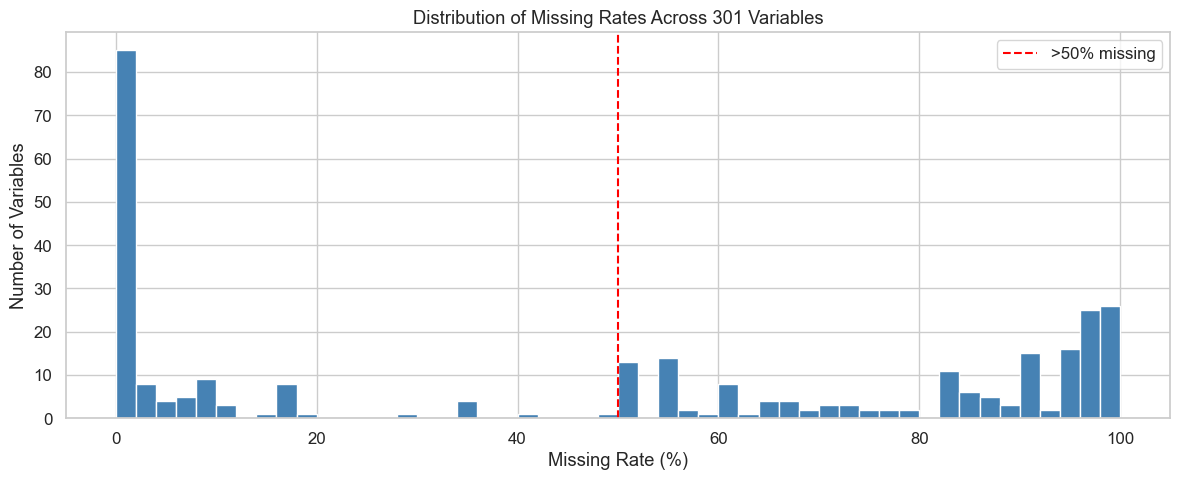

Variables with 0% missing    : 50
Variables with >50% missing  : 170
Variables with <50% missing  : 131


In [3]:
# Distribution of missing rates across all variables
os.makedirs('reports/figures', exist_ok=True)
os.makedirs('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures', exist_ok=True)
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/missing_rate_distribution.png', dpi=150)

fig, ax = plt.subplots(figsize=(12, 5))

missing_pct_all = (df.isnull().sum() / len(df) * 100)

ax.hist(missing_pct_all, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Missing Rate (%)')
ax.set_ylabel('Number of Variables')
ax.set_title('Distribution of Missing Rates Across 301 Variables')

# Annotations
n_zero = (missing_pct_all == 0).sum()
n_high = (missing_pct_all > 50).sum()
n_total = len(missing_pct_all)

ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='>50% missing')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/missing_rate_distribution.png', 
            dpi=150, facecolor='white')
plt.show()

print(f"Variables with 0% missing    : {n_zero}")
print(f"Variables with >50% missing  : {n_high}")
print(f"Variables with <50% missing  : {n_total - n_high}")

#### Audit Findings

- **301 variables** total, all numeric (float64/int64)
- **50 variables** with 0% missing — core variables asked to all respondents
- **170 variables** with >50% missing — module-specific variables asked to subgroups only
- **Overall missing rate: 48.36%** — expected for a survey dataset of this structure

**Design implication:** Feature engineering will focus on the ~130 variables with <50% missing. Variables at 100% missing will be dropped immediately. BRFSS special codes (7/9 series) are not true missing values — they will be recoded explicitly in Section 3.

### Section 2.2 — Target Variable Analysis: DIABETE4 + CDC Benchmark

In [4]:
# --- 2.2 Target Variable Analysis ---

# DIABETE4 value counts
print("--- DIABETE4 Raw Value Counts ---")
print(df['DIABETE4'].value_counts(dropna=False).sort_index())
print()

# BRFSS coding for DIABETE4:
# 1 = Yes
# 2 = Yes, but only during pregnancy
# 3 = No
# 4 = No, pre-diabetes or borderline diabetes
# 7 = Don't know / Not sure
# 9 = Refused
# NaN = Missing

--- DIABETE4 Raw Value Counts ---
DIABETE4
1.0000     65809
2.0000      3395
3.0000    376125
4.0000     11307
7.0000       798
9.0000       232
NaN            4
Name: count, dtype: int64



In [5]:
# --- DIABETE4 Clean Distribution + CDC Benchmark ---

# Recode for analysis
diabete_map = {
    1.0: 'Diabetic',
    2.0: 'Gestational only',
    3.0: 'No',
    4.0: 'Pre-diabetic',
    7.0: 'Don\'t know',
    9.0: 'Refused'
}

df['DIABETE4_label'] = df['DIABETE4'].map(diabete_map)

# Count and percentage
counts = df['DIABETE4_label'].value_counts(dropna=True)
pcts = (counts / counts.sum() * 100).round(2)

dist_df = pd.DataFrame({'Count': counts, 'Percentage': pcts})
print("--- DIABETE4 Distribution ---")
print(dist_df)
print()

# For modeling: binary target
# Positive class = 1 (Diabetic) — exclude gestational, don't know, refused, NaN
df_model = df[df['DIABETE4'].isin([1.0, 3.0, 4.0])].copy()
df_model['TARGET_DIABETES'] = (df_model['DIABETE4'] == 1.0).astype(int)

total = len(df_model)
positive = df_model['TARGET_DIABETES'].sum()
print(f"--- Binary Target for Modeling ---")
print(f"Total usable rows     : {total:,}")
print(f"Diabetic (1)          : {positive:,} ({positive/total*100:.2f}%)")
print(f"Non-diabetic (0)      : {total-positive:,} ({(total-positive)/total*100:.2f}%)")
print()

# C

--- DIABETE4 Distribution ---
                   Count  Percentage
DIABETE4_label                      
No                376125     82.1800
Diabetic           65809     14.3800
Pre-diabetic       11307      2.4700
Gestational only    3395      0.7400
Don't know           798      0.1700
Refused              232      0.0500



/var/folders/39/9v2r64292m98c6c1_qf1hf_r0000gn/T/ipykernel_4831/1613455323.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DIABETE4_label'] = df['DIABETE4'].map(diabete_map)


--- Binary Target for Modeling ---
Total usable rows     : 453,241
Diabetic (1)          : 65,809 (14.52%)
Non-diabetic (0)      : 387,432 (85.48%)



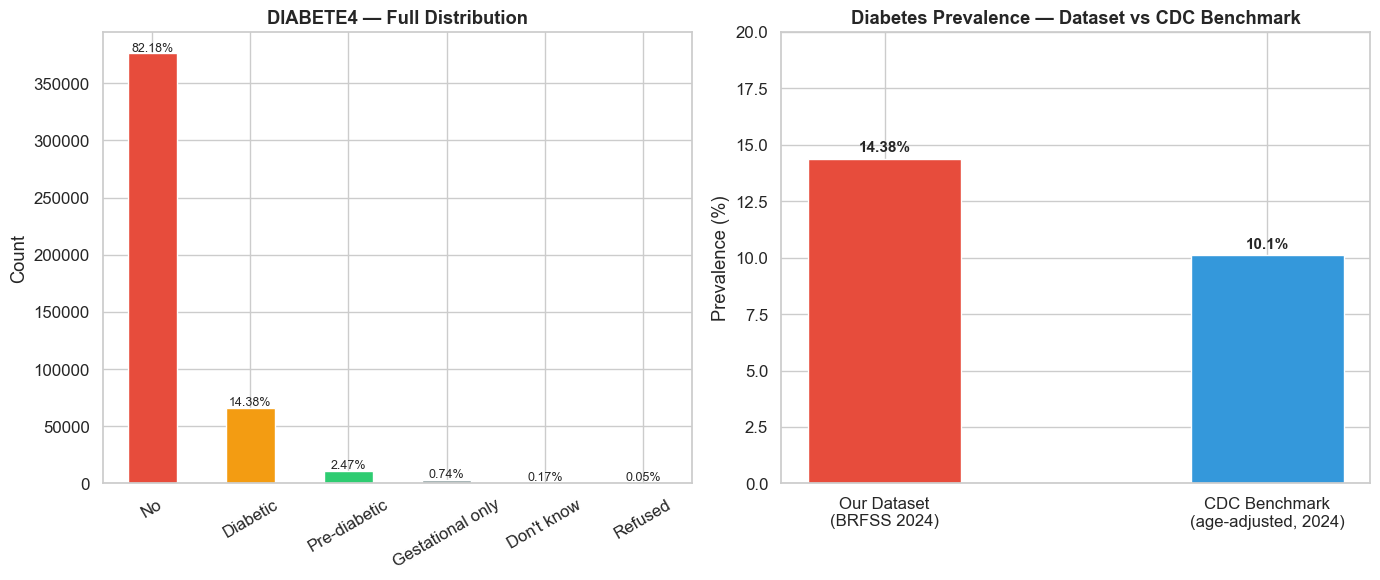

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Full distribution
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6', '#bdc3c7', '#ecf0f1']
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('DIABETE4 — Full Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (count, pct) in enumerate(zip(counts, pcts)):
    axes[0].text(i, count + 2000, f'{pct}%', ha='center', fontsize=9)

# Plot 2 — Binary target vs CDC benchmark
categories = ['Our Dataset\n(BRFSS 2024)', 'CDC Benchmark\n(age-adjusted, 2024)']
values = [14.38, 10.1]
bar_colors = ['#e74c3c', '#3498db']
bars = axes[1].bar(categories, values, color=bar_colors, edgecolor='white', width=0.4)
axes[1].set_title('Diabetes Prevalence — Dataset vs CDC Benchmark', fontweight='bold')
axes[1].set_ylabel('Prevalence (%)')
axes[1].set_ylim(0, 20)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val}%',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/target_distribution.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Target Variable

- **14.38% diabetic rate** in the full dataset vs **10.1% CDC benchmark** (age-adjusted diagnosed diabetes, NCHS Data Brief No.516, Nov 2024)
- The +4.3pp gap is explained by BRFSS sampling bias toward older adults via telephone interviews — no age-adjustment applied here
- **Binary modeling target: 14.52% positive class** — calculated on 453,241 rows after excluding gestational, don't know, refused, and missing values
- **Class imbalance: 85.5% / 14.5%** — moderate imbalance, manageable with class weighting in LightGBM
- **2.47% pre-diabetic** — not yet diabetic but on a trajectory. Captured in the multi-morbidity target in Section 3
- **Gestational, don't know, refused excluded** from modeling target — 3,627 rows removed

**Modeling note:** Binary target `TARGET_DIABETES` defined on 453,241 rows. Positive class = diagnosed diabetes (DIABETE4 = 1).

### Section 2.3 — Demographic Variables

Variables analyzed: `SEXVAR`, `_AGEG5YR`, `MARITAL`, `EDUCA`, `RENTHOM1`, `VETERAN3`, `CHILDREN`

These variables describe who the respondents are. The goal here is to understand how demographic profiles correlate with diabetes risk — key input for the insurer's member segmentation.

In [7]:
# --- 2.3 Demographic Variables ---

# Variables and their BRFSS coding
demo_vars = {
    'SEXVAR'  : {1: 'Male', 2: 'Female'},
    '_AGEG5YR': {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
                 6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
                 11: '70-74', 12: '75-79', 13: '80+', 14: 'Don\'t know/refused'},
    'MARITAL' : {1: 'Married', 2: 'Divorced', 3: 'Widowed', 4: 'Separated',
                 5: 'Never married', 6: 'Unmarried couple', 9: 'Refused'},
    'EDUCA'   : {1: 'No school', 2: 'Elementary', 3: 'Some high school',
                 4: 'High school grad', 5: 'Some college', 6: 'College grad', 9: 'Refused'},
    'RENTHOM1': {1: 'Own', 2: 'Rent', 3: 'Other', 7: 'Don\'t know', 9: 'Refused'},
    'VETERAN3': {1: 'Veteran', 2: 'Non-veteran', 7: 'Don\'t know', 9: 'Refused'},
}

# Print raw distributions
for var, mapping in demo_vars.items():
    if var in df.columns:
        print(f"--- {var} ---")
        vc = df[var].value_counts(dropna=False).sort_index()
        print(vc)
        print()

--- SEXVAR ---
SEXVAR
1.0000    217487
2.0000    240183
Name: count, dtype: int64

--- _AGEG5YR ---
_AGEG5YR
1.0000     29692
2.0000     23705
3.0000     26237
4.0000     28804
5.0000     30899
6.0000     28968
7.0000     31698
8.0000     34936
9.0000     43387
10.0000    47701
11.0000    44774
12.0000    36803
13.0000    41756
14.0000     8310
Name: count, dtype: int64

--- MARITAL ---
MARITAL
1.0000    229393
2.0000     58827
3.0000     49161
4.0000      9462
5.0000     84851
6.0000     21754
9.0000      4213
NaN            9
Name: count, dtype: int64

--- EDUCA ---
EDUCA
1.0000       723
2.0000      9226
3.0000     17200
4.0000    115877
5.0000    120732
6.0000    191549
9.0000      2356
NaN            7
Name: count, dtype: int64

--- RENTHOM1 ---
RENTHOM1
1.0000    312589
2.0000    118460
3.0000     22677
7.0000      1101
9.0000      2835
NaN            8
Name: count, dtype: int64

--- VETERAN3 ---
VETERAN3
1.0000     52504
2.0000    402590
7.0000       187
9.0000      1154
NaN    

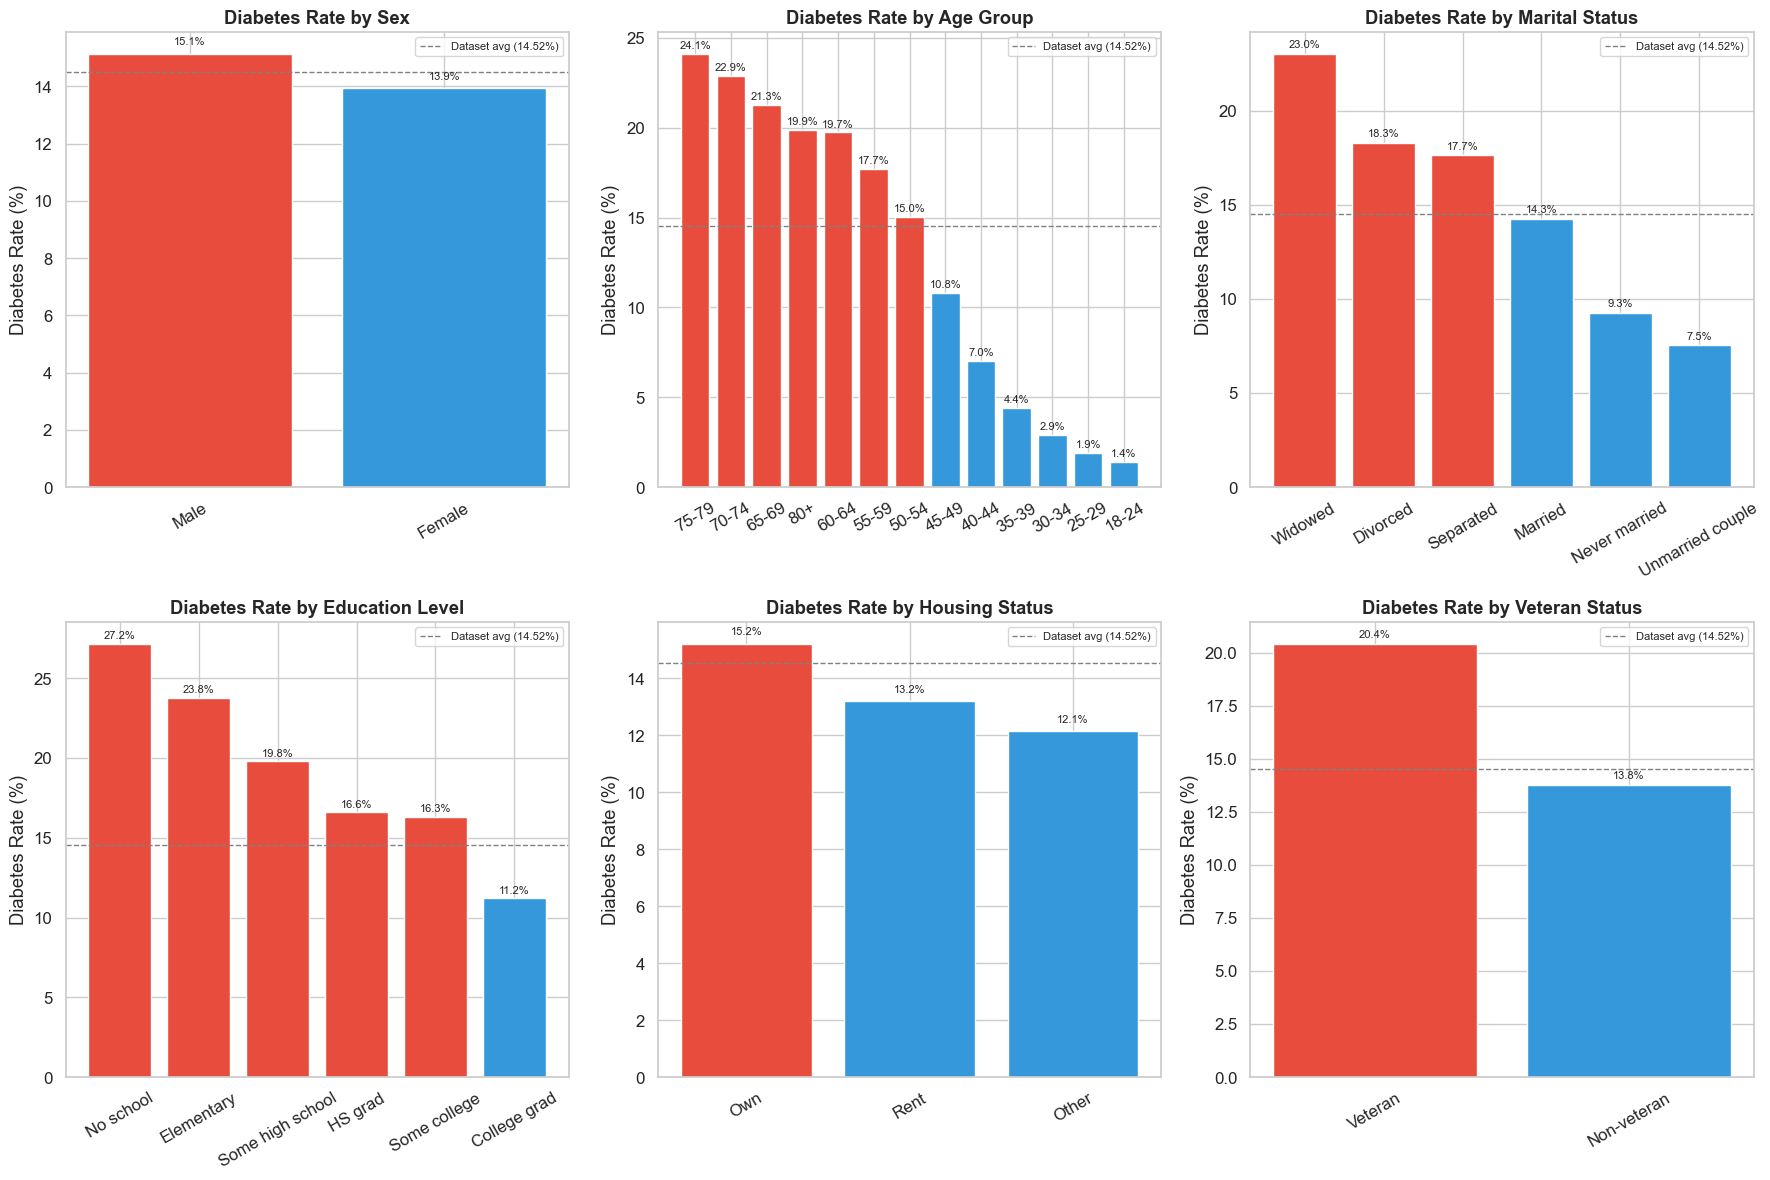

In [8]:
# --- Diabetes rate by demographic group ---

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Working on df_model which has TARGET_DIABETES
demo_plots = [
    ('SEXVAR',   {1.0: 'Male', 2.0: 'Female'}, 'Sex'),
    ('_AGEG5YR', {1.0: '18-24', 2.0: '25-29', 3.0: '30-34', 4.0: '35-39',
                  5.0: '40-44', 6.0: '45-49', 7.0: '50-54', 8.0: '55-59',
                  9.0: '60-64', 10.0: '65-69', 11.0: '70-74', 12.0: '75-79',
                  13.0: '80+'}, 'Age Group'),
    ('MARITAL',  {1.0: 'Married', 2.0: 'Divorced', 3.0: 'Widowed',
                  4.0: 'Separated', 5.0: 'Never married', 6.0: 'Unmarried couple'}, 'Marital Status'),
    ('EDUCA',    {1.0: 'No school', 2.0: 'Elementary', 3.0: 'Some high school',
                  4.0: 'HS grad', 5.0: 'Some college', 6.0: 'College grad'}, 'Education Level'),
    ('RENTHOM1', {1.0: 'Own', 2.0: 'Rent', 3.0: 'Other'}, 'Housing Status'),
    ('VETERAN3', {1.0: 'Veteran', 2.0: 'Non-veteran'}, 'Veteran Status'),
]

for idx, (var, mapping, title) in enumerate(demo_plots):
    ax = axes[idx]

    # Filter valid values only
    valid_vals = list(mapping.keys())
    temp = df_model[df_model[var].isin(valid_vals)].copy()
    temp['label'] = temp[var].map(mapping)

    # Diabetes rate by group
    rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
    rates = rates.sort_values(ascending=False)

    bars = ax.bar(rates.index, rates.values,
                  color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                  edgecolor='white')
    ax.axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg (14.52%)')
    ax.set_title(f'Diabetes Rate by {title}', fontweight='bold')
    ax.set_ylabel('Diabetes Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/demographics_diabetes_rate.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Demographics

**Sex:** Males show a slightly higher diabetes rate (15.1%) vs females (13.9%). Modest gap but consistent with CDC literature.

**Age:** Strong monotonic relationship — risk increases sharply with age. 75-79 age group peaks at 24.1%. Below 40, risk drops under 5%. Age is likely the strongest single demographic predictor.

**Marital Status:** Widowed (23.0%) and divorced (18.3%) show elevated risk — likely confounded by age. Never married and unmarried couples show the lowest rates, reflecting a younger population.

**Education:** Clear inverse gradient — no schooling at 27.2% down to college graduates at 11.2%. Education is a strong socioeconomic proxy for diabetes risk, actionable for insurer segmentation.

**Housing:** Homeowners (15.2%) show marginally higher rates than renters (13.2%) — likely an age confound again, as older adults are more likely to own homes.

**Veteran Status:** Veterans show notably higher rates (20.4%) vs non-veterans (13.8%). A segment worth targeting specifically in prevention programs.

**Business implication:** Age and education are the two strongest demographic levers for risk segmentation. Veterans represent a high-risk niche segment.

### Section 2.4 — Income & Employment Variables

Variables analyzed: `INCOME3`, `EMPLOY1`

Income and employment status are key socioeconomic determinants of chronic disease risk. For the insurer, they also serve as proxies for healthcare access barriers.

In [9]:
# --- 2.4 Income & Employment ---

print("--- INCOME3 ---")
print(df['INCOME3'].value_counts(dropna=False).sort_index())
print()
print("--- EMPLOY1 ---")
print(df['EMPLOY1'].value_counts(dropna=False).sort_index())

--- INCOME3 ---
INCOME3
1.0000     10258
2.0000     10542
3.0000     13662
4.0000     19841
5.0000     41702
6.0000     49686
7.0000     60709
8.0000     51700
9.0000     55778
10.0000    26675
11.0000    29694
77.0000    37113
99.0000    41041
NaN         9269
Name: count, dtype: int64

--- EMPLOY1 ---
EMPLOY1
1.0000    186378
2.0000     39146
3.0000      8953
4.0000     10812
5.0000     17832
6.0000     11473
7.0000    146916
8.0000     27758
9.0000      5099
NaN         3303
Name: count, dtype: int64


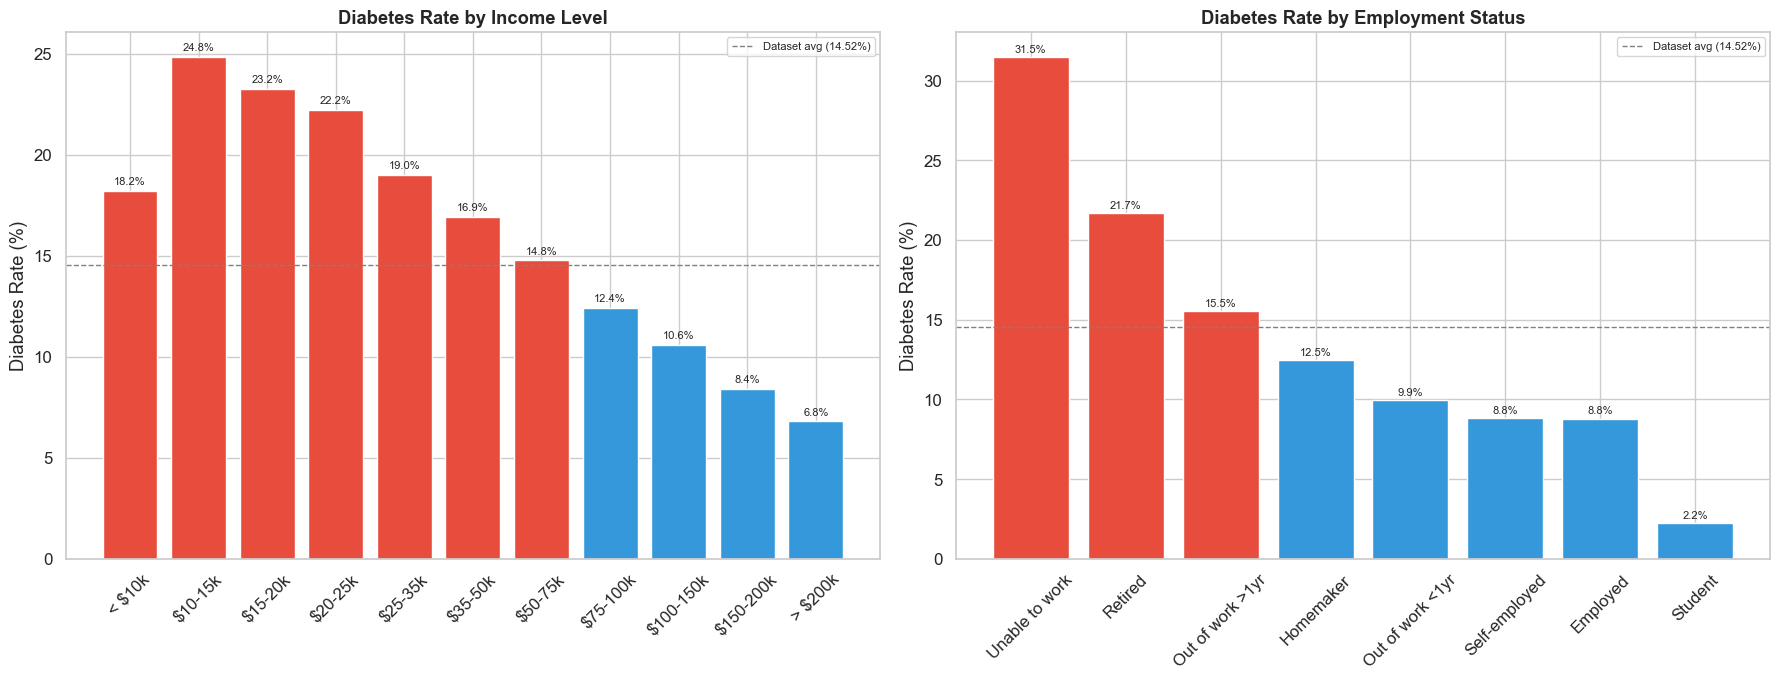

In [10]:
# --- Diabetes rate by Income and Employment ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Income mapping (BRFSS 2024 INCOME3 coding)
income_map = {
    1.0:  '< $10k',
    2.0:  '$10-15k',
    3.0:  '$15-20k',
    4.0:  '$20-25k',
    5.0:  '$25-35k',
    6.0:  '$35-50k',
    7.0:  '$50-75k',
    8.0:  '$75-100k',
    9.0:  '$100-150k',
    10.0: '$150-200k',
    11.0: '> $200k'
}

employ_map = {
    1.0: 'Employed',
    2.0: 'Self-employed',
    3.0: 'Out of work >1yr',
    4.0: 'Out of work <1yr',
    5.0: 'Homemaker',
    6.0: 'Student',
    7.0: 'Retired',
    8.0: 'Unable to work',
}

# Plot 1 — Income
temp_inc = df_model[df_model['INCOME3'].isin(income_map.keys())].copy()
temp_inc['label'] = temp_inc['INCOME3'].map(income_map)
rates_inc = temp_inc.groupby('label')['TARGET_DIABETES'].mean() * 100
# Preserve income order
ordered_labels = [v for k, v in sorted(income_map.items())]
rates_inc = rates_inc.reindex(ordered_labels)

bars = axes[0].bar(rates_inc.index, rates_inc.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates_inc.values],
                   edgecolor='white')
axes[0].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg (14.52%)')
axes[0].set_title('Diabetes Rate by Income Level', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, rates_inc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)

# Plot 2 — Employment
temp_emp = df_model[df_model['EMPLOY1'].isin(employ_map.keys())].copy()
temp_emp['label'] = temp_emp['EMPLOY1'].map(employ_map)
rates_emp = temp_emp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates_emp = rates_emp.sort_values(ascending=False)

bars2 = axes[1].bar(rates_emp.index, rates_emp.values,
                    color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates_emp.values],
                    edgecolor='white')
axes[1].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg (14.52%)')
axes[1].set_title('Diabetes Rate by Employment Status', fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, rates_emp.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/income_employment_diabetes_rate.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Income & Employment

**Income:** Strong inverse gradient — diabetes rate drops from 24.8% at $10-15k to 6.8% above $200k. The inflection point sits around $50-75k where the rate crosses the dataset average. Low income is one of the strongest socioeconomic predictors of diabetes risk, likely driven by food environment, healthcare access, and chronic stress.

**Employment:** Three high-risk segments stand out clearly. Unable to work at 31.5% — the highest rate in the dataset, combining poor health, low income, and limited healthcare access. Retired at 21.7% — largely an age effect. Out of work >1yr at 15.5% — unemployment duration compounds risk through stress and loss of employer-sponsored insurance.

Students at 2.2% represent the lowest risk segment, consistent with their younger age profile.

**Business implication:** Low-income and unable-to-work segments should be priority targets for prevention outreach. These are also the segments least likely to self-initiate healthcare contact, making proactive insurer intervention highest value.

### Section 2.5 — Behavioral Variables

Variables analyzed: `SMOKE100`, `SMOKDAY2`, `ECIGNOW3`, `ALCDAY4`, `DRNK3GE5`, `EXERANУ2`

Behavioral variables are the most actionable lever for prevention programs. Unlike age or income, behaviors can be modified. For the insurer, identifying which behaviors most strongly predict diabetes risk directly informs program design.

In [11]:
# --- 2.5 Behavioral Variables raw distributions ---

behavioral_vars = ['SMOKE100', 'SMOKDAY2', 'ECIGNOW3', 'ALCDAY4', 'DRNK3GE5', 'EXERANY2']

for var in behavioral_vars:
    if var in df.columns:
        print(f"--- {var} ---")
        print(df[var].value_counts(dropna=False).sort_index())
        print()
    else:
        print(f"--- {var} NOT FOUND ---")
        print()

--- SMOKE100 ---
SMOKE100
1.0000    167242
2.0000    258956
7.0000      2062
9.0000       550
NaN        28860
Name: count, dtype: int64

--- SMOKDAY2 ---
SMOKDAY2
1.0000     33118
2.0000     13976
3.0000    119598
7.0000       194
9.0000       190
NaN       290594
Name: count, dtype: int64

--- ECIGNOW3 ---
ECIGNOW3
1.0000    343250
2.0000     13123
3.0000     11383
4.0000     57163
7.0000      1168
9.0000       907
NaN        30676
Name: count, dtype: int64

--- ALCDAY4 ---
ALCDAY4
100.0000         1
101.0000     19949
102.0000     15899
103.0000     11426
104.0000      5593
105.0000      5488
106.0000      1761
107.0000      5913
201.0000     34424
202.0000     25375
203.0000     14523
204.0000     10978
205.0000     10501
206.0000      3686
207.0000      2735
208.0000      3120
209.0000       275
210.0000      6950
211.0000        38
212.0000      1634
213.0000        99
214.0000       590
215.0000      5457
216.0000       214
217.0000        81
218.0000       208
219.0000        1

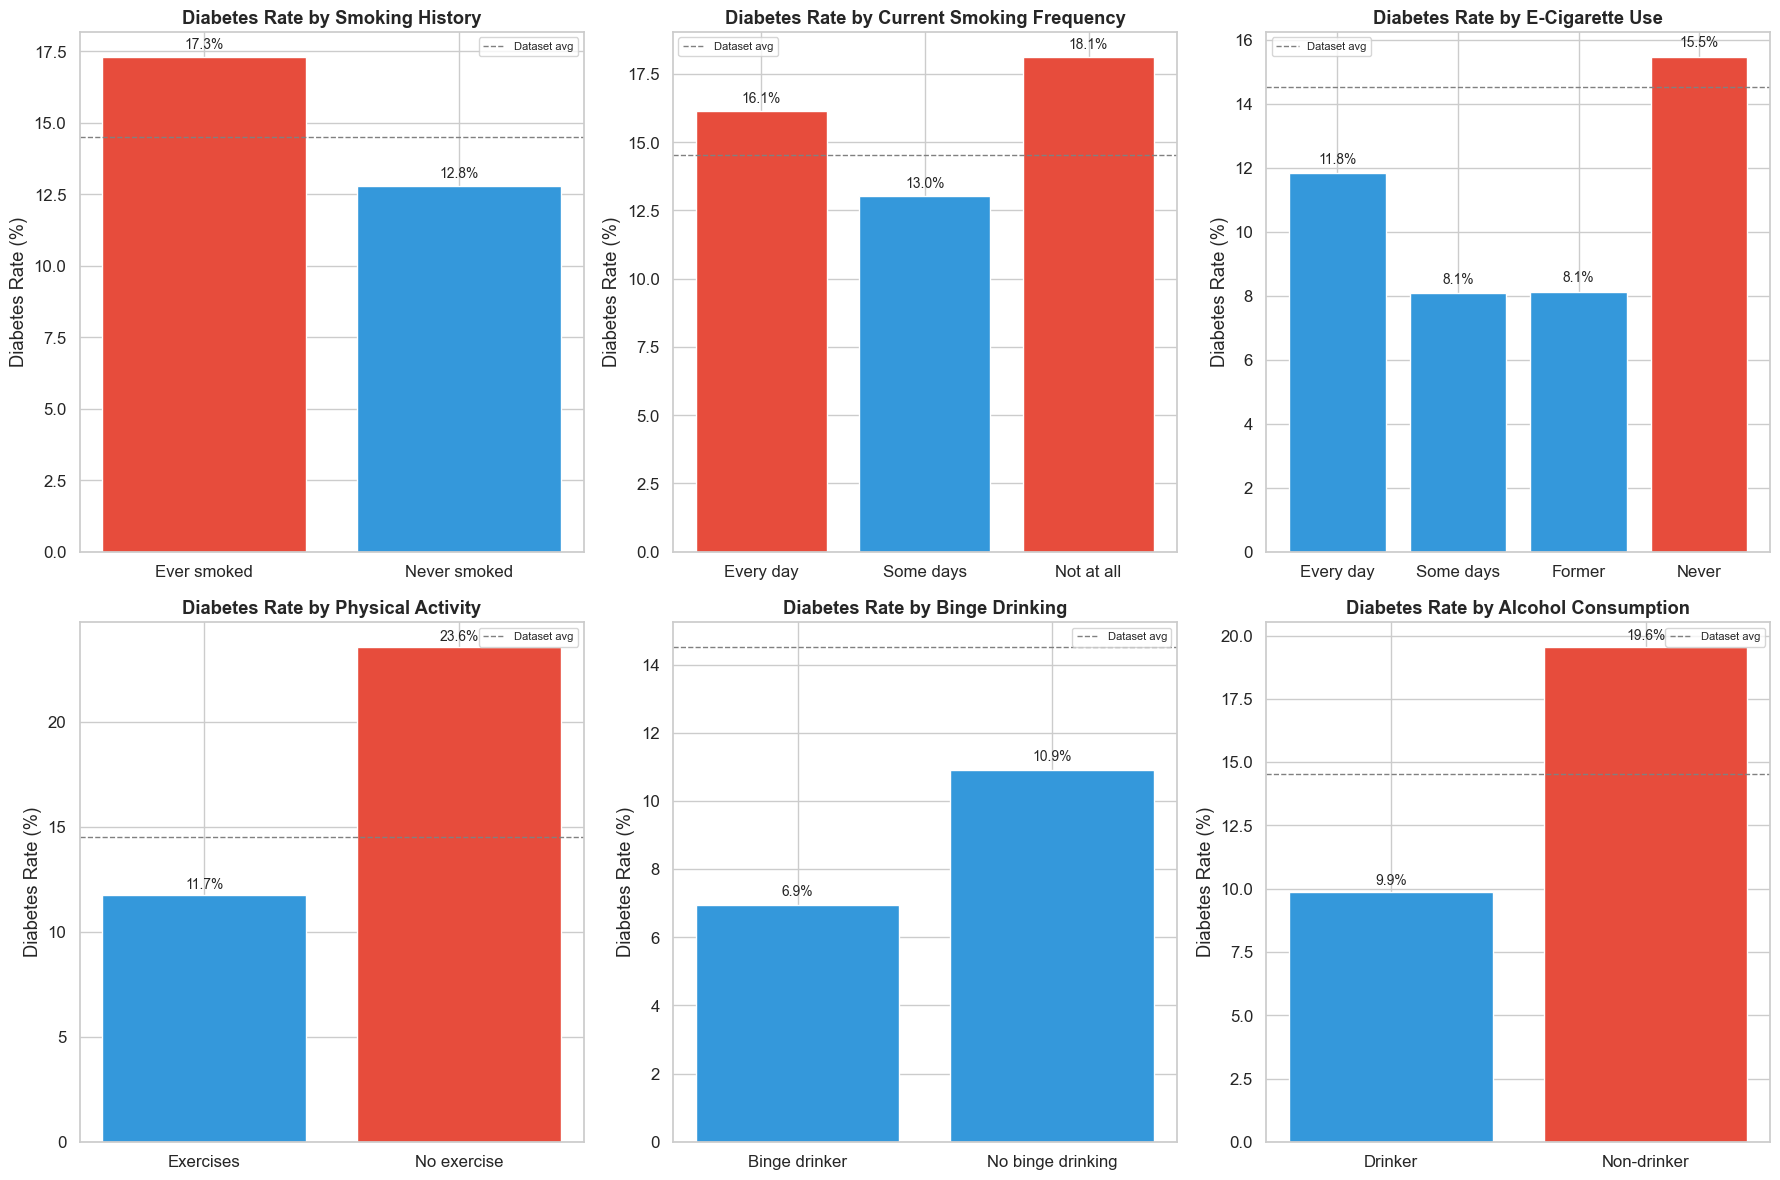

In [12]:
# --- Diabetes rate by behavioral variables ---

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 1. Smoked 100+ cigarettes in life
temp = df_model[df_model['SMOKE100'].isin([1.0, 2.0])].copy()
temp['label'] = temp['SMOKE100'].map({1.0: 'Ever smoked', 2.0: 'Never smoked'})
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
bars = axes[0].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[0].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[0].set_title('Diabetes Rate by Smoking History', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 2. Current smoking frequency
temp = df_model[df_model['SMOKDAY2'].isin([1.0, 2.0, 3.0])].copy()
temp['label'] = temp['SMOKDAY2'].map({1.0: 'Every day', 2.0: 'Some days', 3.0: 'Not at all'})
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.reindex(['Every day', 'Some days', 'Not at all'])
bars = axes[1].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[1].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[1].set_title('Diabetes Rate by Current Smoking Frequency', fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 3. E-cigarette use
temp = df_model[df_model['ECIGNOW3'].isin([1.0, 2.0, 3.0, 4.0])].copy()
temp['label'] = temp['ECIGNOW3'].map({1.0: 'Never', 2.0: 'Former',
                                       3.0: 'Some days', 4.0: 'Every day'})
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.reindex(['Every day', 'Some days', 'Former', 'Never'])
bars = axes[2].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[2].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[2].set_title('Diabetes Rate by E-Cigarette Use', fontweight='bold')
axes[2].set_ylabel('Diabetes Rate (%)')
axes[2].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 4. Physical activity
temp = df_model[df_model['EXERANY2'].isin([1.0, 2.0])].copy()
temp['label'] = temp['EXERANY2'].map({1.0: 'Exercises', 2.0: 'No exercise'})
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
bars = axes[3].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[3].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[3].set_title('Diabetes Rate by Physical Activity', fontweight='bold')
axes[3].set_ylabel('Diabetes Rate (%)')
axes[3].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[3].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 5. Binge drinking (DRNK3GE5 — 88 = no binge, 77 = don't know, 99 = refused)
temp = df_model[df_model['DRNK3GE5'].notna()].copy()
temp = temp[~temp['DRNK3GE5'].isin([77.0, 99.0])]
temp['binge'] = temp['DRNK3GE5'].apply(lambda x: 'No binge drinking' if x == 88.0 else 'Binge drinker')
rates = temp.groupby('binge')['TARGET_DIABETES'].mean() * 100
bars = axes[4].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[4].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[4].set_title('Diabetes Rate by Binge Drinking', fontweight='bold')
axes[4].set_ylabel('Diabetes Rate (%)')
axes[4].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[4].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 6. Alcohol consumption (ALCDAY4 — 888 = no drinks)
temp = df_model[df_model['ALCDAY4'].notna()].copy()
temp = temp[~temp['ALCDAY4'].isin([777.0, 999.0])]
temp['alcohol'] = temp['ALCDAY4'].apply(lambda x: 'Non-drinker' if x == 888.0 else 'Drinker')
rates = temp.groupby('alcohol')['TARGET_DIABETES'].mean() * 100
bars = axes[5].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[5].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[5].set_title('Diabetes Rate by Alcohol Consumption', fontweight='bold')
axes[5].set_ylabel('Diabetes Rate (%)')
axes[5].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[5].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/behavioral_diabetes_rate.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Behavioral Variables

**Physical activity:** The strongest and cleanest behavioral signal. Sedentary respondents show a 23.6% diabetes rate vs 11.7% for those who exercise — a 2x difference. Physical inactivity is the most actionable behavioral lever in this dataset.

**Smoking history:** Ever-smokers show a higher rate (17.3%) vs never-smokers (12.8%). Consistent with known literature linking smoking to insulin resistance.

**Current smoking frequency:** Counterintuitively, "Not at all" current smokers show the highest rate (18.1%). This is a classic age confound — many older diabetics have already quit smoking after diagnosis. The variable measures current behavior, not lifetime exposure.

**E-cigarettes:** Daily e-cigarette users show the lowest diabetes rate (11.8%) while never-users show 15.5%. This is a pure age effect — e-cigarette use is concentrated among younger adults who have inherently low diabetes risk. No causal interpretation possible here.

**Binge drinking:** Binge drinkers show a lower rate (6.9%) than non-binge drinkers (10.9%). Again, an age and reverse causality effect — diabetic patients are more likely to have stopped or reduced alcohol consumption following diagnosis.

**Alcohol consumption:** Non-drinkers at 19.6% vs drinkers at 9.9% — same reverse causality dynamic as binge drinking.

**Business implication:** Physical inactivity is the only behavioral variable with a clean, actionable signal at this stage. Smoking history is a secondary signal. Alcohol and e-cigarette variables require age-adjusted analysis before drawing conclusions — handled in Section 5.

### Section 2.6 — Healthcare Access Variables

Variables analyzed: `PRIMINS2`, `PERSDOC3`, `MEDCOST1`, `CHECKUP1`

Healthcare access is a critical dimension for the insurer. Members who lack coverage, a personal doctor, or who avoid care due to cost are less likely to be diagnosed early — and more likely to arrive as expensive late-stage claims.

In [13]:
# --- 2.6 Healthcare Access raw distributions ---

access_vars = ['PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1']

for var in access_vars:
    if var in df.columns:
        print(f"--- {var} ---")
        print(df[var].value_counts(dropna=False).sort_index())
        print()
    else:
        print(f"--- {var} NOT FOUND ---")
        print()

--- PRIMINS2 ---
PRIMINS2
1.0000     155360
2.0000      38611
3.0000     145567
4.0000        386
5.0000      32847
6.0000        144
7.0000      16939
8.0000       1409
9.0000      12329
10.0000     10128
77.0000     12524
88.0000     25406
99.0000      6017
NaN             3
Name: count, dtype: int64

--- PERSDOC3 ---
PERSDOC3
1.0000    242393
2.0000    154558
3.0000     56106
7.0000      3446
9.0000      1164
NaN            3
Name: count, dtype: int64

--- MEDCOST1 ---
MEDCOST1
1.0000     43363
2.0000    412634
7.0000      1229
9.0000       438
NaN            6
Name: count, dtype: int64

--- CHECKUP1 ---
CHECKUP1
1.0000    370023
2.0000     39655
3.0000     21480
4.0000     18395
7.0000      4615
8.0000      2783
9.0000       717
NaN            2
Name: count, dtype: int64



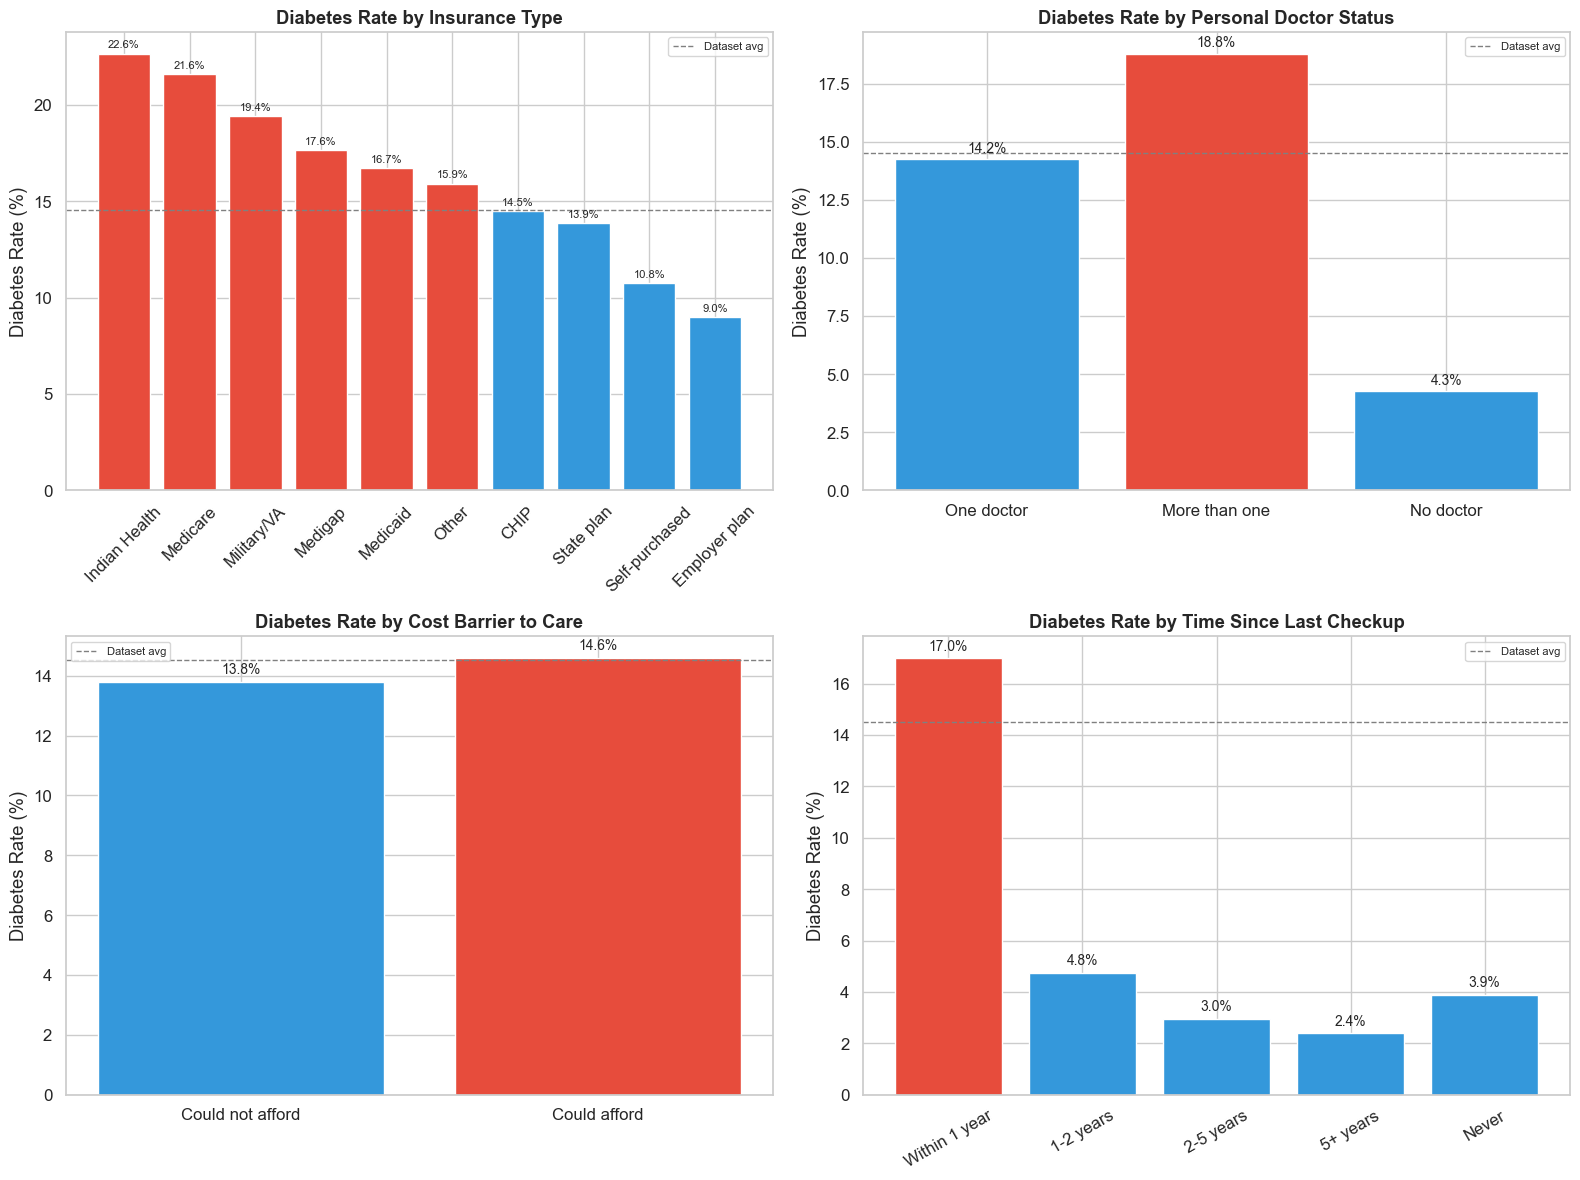

In [14]:
# --- Diabetes rate by healthcare access variables ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Primary insurance source
primins_map = {
    1.0:  'Employer plan',
    2.0:  'Self-purchased',
    3.0:  'Medicare',
    4.0:  'Medigap',
    5.0:  'Medicaid',
    6.0:  'CHIP',
    7.0:  'Military/VA',
    8.0:  'Indian Health',
    9.0:  'State plan',
    10.0: 'Other'
}
temp = df_model[df_model['PRIMINS2'].isin(primins_map.keys())].copy()
temp['label'] = temp['PRIMINS2'].map(primins_map)
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.sort_values(ascending=False)
bars = axes[0].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[0].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[0].set_title('Diabetes Rate by Insurance Type', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)

# 2. Personal doctor
persdoc_map = {
    1.0: 'One doctor',
    2.0: 'More than one',
    3.0: 'No doctor'
}
temp = df_model[df_model['PERSDOC3'].isin(persdoc_map.keys())].copy()
temp['label'] = temp['PERSDOC3'].map(persdoc_map)
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.reindex(['One doctor', 'More than one', 'No doctor'])
bars = axes[1].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[1].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[1].set_title('Diabetes Rate by Personal Doctor Status', fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 3. Could not afford doctor
medcost_map = {1.0: 'Could not afford', 2.0: 'Could afford'}
temp = df_model[df_model['MEDCOST1'].isin(medcost_map.keys())].copy()
temp['label'] = temp['MEDCOST1'].map(medcost_map)
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.reindex(['Could not afford', 'Could afford'])
bars = axes[2].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[2].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[2].set_title('Diabetes Rate by Cost Barrier to Care', fontweight='bold')
axes[2].set_ylabel('Diabetes Rate (%)')
axes[2].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# 4. Time since last checkup
checkup_map = {
    1.0: 'Within 1 year',
    2.0: '1-2 years',
    3.0: '2-5 years',
    4.0: '5+ years',
    8.0: 'Never'
}
temp = df_model[df_model['CHECKUP1'].isin(checkup_map.keys())].copy()
temp['label'] = temp['CHECKUP1'].map(checkup_map)
rates = temp.groupby('label')['TARGET_DIABETES'].mean() * 100
rates = rates.reindex(['Within 1 year', '1-2 years', '2-5 years', '5+ years', 'Never'])
bars = axes[3].bar(rates.index, rates.values,
                   color=['#e74c3c' if v > 14.52 else '#3498db' for v in rates.values],
                   edgecolor='white')
axes[3].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg')
axes[3].set_title('Diabetes Rate by Time Since Last Checkup', fontweight='bold')
axes[3].set_ylabel('Diabetes Rate (%)')
axes[3].tick_params(axis='x', rotation=30)
axes[3].legend(fontsize=8)
for bar, val in zip(bars, rates.values):
    axes[3].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/healthcare_access_diabetes_rate.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Healthcare Access

**Insurance type:** Indian Health Service (22.6%) and Medicare (21.6%) show the highest rates. Indian Health reflects the well-documented elevated diabetes prevalence among Native American populations. Medicare is an age effect — it covers adults 65+.

**Personal doctor:** Respondents with more than one doctor show the highest rate (18.8%) — a selection effect, not a causal one. People already managing chronic conditions accumulate multiple specialists. No doctor at 4.3% reflects a younger, healthier, undiagnosed population.

**Cost barrier:** Near-negligible gap — 14.6% for those who could afford care vs 13.8% for those who could not. The cost barrier variable is a weak univariate signal, likely masking an under-diagnosis effect: those who cannot afford care are less likely to receive a formal diagnosis.

**Time since last checkup:** "Within 1 year" peaks at 17.0% — a reverse causality effect. Diabetics consult more frequently by necessity. The low rates for 5+ years (2.4%) and Never (3.9%) reflect a younger, undiagnosed population, not a healthier one.

**Business implication:** Insurance type is a strong segmentation signal, particularly Medicare and Indian Health populations. The cost barrier and checkup frequency variables require careful interpretation — they reflect healthcare utilization patterns driven by existing disease, not upstream risk factors.

### Section 2.7 — Geographic Analysis

Variable analyzed: `_STATE`

Geographic disparities in diabetes prevalence are critical for the insurer's regional prevention strategy. States with high prevalence and low healthcare access represent the highest-priority intervention zones.

In [15]:
# --- 2.7 Geographic Analysis ---

# State FIPS to state abbreviation mapping
fips_to_state = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT',
    10: 'DE', 11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL',
    18: 'IN', 19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD',
    25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE',
    32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD',
    47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 66: 'GU', 72: 'PR', 78: 'VI'
}

# Map state
df_model['STATE'] = df_model['_STATE'].map(fips_to_state)

# Diabetes rate by state
state_rates = df_model.groupby('STATE').agg(
    diabetes_rate=('TARGET_DIABETES', 'mean'),
    n=('TARGET_DIABETES', 'count')
).reset_index()
state_rates['diabetes_rate_pct'] = (state_rates['diabetes_rate'] * 100).round(2)
state_rates = state_rates.sort_values('diabetes_rate_pct', ascending=False)

print("--- Top 10 States by Diabetes Rate ---")
print(state_rates.head(10).to_string(index=False))
print()
print("--- Bottom 10 States by Diabetes Rate ---")
print(state_rates.tail(10).to_string(index=False))

--- Top 10 States by Diabetes Rate ---
STATE  diabetes_rate    n  diabetes_rate_pct
   WV         0.2171 5753            21.7100
   KY         0.2028 7383            20.2800
   GU         0.1971 1634            19.7100
   SC         0.1960 9382            19.6000
   AL         0.1918 5047            19.1800
   PR         0.1898 4293            18.9800
   AR         0.1896 5286            18.9600
   VA         0.1787 6805            17.8700
   LA         0.1784 4496            17.8400
   VI         0.1730 1335            17.3000

--- Bottom 10 States by Diabetes Rate ---
STATE  diabetes_rate     n  diabetes_rate_pct
   WA         0.1216 25541            12.1600
   NJ         0.1208  8584            12.0800
   MN         0.1184 15045            11.8400
   ID         0.1140  4316            11.4000
   UT         0.1114 12628            11.1400
   DC         0.1113  3172            11.1300
   AK         0.1100  5437            11.0000
   MA         0.1065  9396            10.6500
   VT    

In [17]:
# --- Choropleth map — Diabetes rate by state ---

fig = px.choropleth(
    state_rates,
    locations='STATE',
    locationmode='USA-states',
    color='diabetes_rate_pct',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    range_color=[8, 22],
    labels={'diabetes_rate_pct': 'Diabetes Rate (%)'},
    title='Diabetes Prevalence by State — BRFSS 2024',
    hover_data={'STATE': True, 'diabetes_rate_pct': True, 'n': True}
)

fig.update_layout(
    title_font_size=16,
    geo=dict(showlakes=False),
    coloraxis_colorbar=dict(title='Diabetes Rate (%)'),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/diabetes_rate_by_state.html')
fig.show()

# Static version for reports
fig.write_image('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/diabetes_rate_by_state.png',
                width=1200, height=700)
print("Map saved ✅")

Map saved ✅


#### Key Findings — Geographic Analysis

**The Diabetes Belt is clearly visible.** West Virginia (21.7%), Kentucky (20.3%), and South Carolina (19.6%) lead the ranking. These states share a profile of high poverty rates, limited healthcare infrastructure, sedentary lifestyle, and food deserts.

**The West and Northeast show the lowest rates.** Colorado (9.8%), Vermont (10.5%), and Massachusetts (10.6%) benefit from higher education levels, stronger healthcare access, and more active lifestyles.

**12-point gap between highest and lowest states.** West Virginia at 21.7% vs Colorado at 9.8% — a 2.2x difference. Geography is one of the strongest risk signals in this dataset.

**Territories show elevated rates.** Guam (19.7%) and Puerto Rico (19.0%) reflect the combined effect of genetic predisposition, dietary patterns, and healthcare access constraints.

**Business implication for MutuelSanté:** Regional prevention budgets should be heavily weighted toward Appalachian and Southeastern states. A member in West Virginia carries more than twice the diabetes risk of a member in Colorado — this should be reflected in both premium pricing and prevention program allocation.

### Section 2.8 — EDA Summary

This section consolidates the key signals identified across all exploratory analyses into actionable business insights.

---

#### What We Learned

**Strongest predictors identified:**

| Variable | Key Signal | Business Relevance |
|---|---|---|
| Age | Risk doubles above 60 — peaks at 24.1% for 75-79 | Primary segmentation criterion |
| Income | 24.8% at $10-15k vs 6.8% above $200k | Socioeconomic risk proxy |
| Education | 27.2% no schooling vs 11.2% college grad | Prevention program targeting |
| Physical inactivity | 23.6% sedentary vs 11.7% active | Most actionable behavioral lever |
| Employment | 31.5% unable to work — highest in dataset | High-priority outreach segment |
| Geography | 21.7% West Virginia vs 9.8% Colorado | Regional budget allocation |
| Insurance type | Medicare (21.6%) and Indian Health (22.6%) | High-risk member segments |
| Veteran status | 20.4% vs 13.8% non-veterans | Niche high-risk segment |
| Smoking history | 17.3% ever-smoked vs 12.8% never | Secondary behavioral signal |

---

#### Variables Requiring Caution

| Variable | Issue |
|---|---|
| E-cigarette use | Age confound — young users skew rates down |
| Alcohol consumption | Reverse causality — diabetics drink less post-diagnosis |
| Binge drinking | Same reverse causality issue |
| Personal doctor count | Selection effect — sick people have more doctors |
| Checkup frequency | Reverse causality — diabetics consult more |

---

#### Modeling Hypotheses

1. Age, income, education, and physical inactivity will be among the top SHAP features in the final model
2. Geographic features (state-level aggregations) will add predictive signal beyond individual-level variables
3. Behavioral variables will require age-adjusted treatment to extract clean signal

---

#### Next Steps

Feature engineering in Section 3 will operationalize these signals into model-ready variables: BMI calculation, behavioral risk score, multi-morbidity score, and geographic aggregations.

## Section 3 — Feature Engineering

### Section 3.1 — Data Cleaning

Before creating new features, we need a clean working dataframe. This involves:
- Dropping variables with >50% missing rate
- Recoding BRFSS special codes (7/9 series) to NaN
- Keeping only modeling-relevant variables
- Resetting on the binary target population (df_model)

In [18]:
# --- 3.1 Data Cleaning ---

# Step 1 — Drop variables with >50% missing
missing_pct_all = (df.isnull().sum() / len(df) * 100)
cols_to_keep = missing_pct_all[missing_pct_all <= 50].index.tolist()
print(f"Variables kept (<= 50% missing) : {len(cols_to_keep)}")
print(f"Variables dropped (> 50% missing): {len(df.columns) - len(cols_to_keep)}")

# Step 2 — Work on binary target population
df_clean = df_model[cols_to_keep].copy()
print(f"\nWorking dataframe shape: {df_clean.shape}")

# Step 3 — Recode BRFSS special codes to NaN
# Pattern: 7/77/777 = don't know, 9/99/999 = refused
def recode_brfss_special(series):
    s = series.copy()
    unique_vals = s.dropna().unique()
    for val in unique_vals:
        if val in [7, 9, 77, 99, 777, 999, 7777, 9999, 77777, 99999]:
            s = s.replace(val, np.nan)
    return s

# Apply to all columns except identifiers and target
exclude_cols = ['_STATE', 'SEQNO', '_PSU', 'DIABETE4', 
                'TARGET_DIABETES', 'DIABETE4_label', 'STATE']
cols_to_recode = [c for c in df_clean.columns if c not in exclude_cols]

for col in cols_to_recode:
    df_clean[col] = recode_brfss_special(df_clean[col])

print("\nSpecial codes recoded to NaN ✅")

# Step 4 — Check missing rates after recoding
missing_after = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)
print("\n--- Top 10 Variables by Missing Rate After Recoding ---")
print(missing_after.head(10))

Variables kept (<= 50% missing) : 132
Variables dropped (> 50% missing): 170

Working dataframe shape: (453241, 132)

Special codes recoded to NaN ✅

--- Top 10 Variables by Missing Rate After Recoding ---
_LCSPSTF   93.4739
_CHISPNC   87.9903
_DUALUSE   69.8595
HEATTBCO   49.3415
INCOME3    44.5397
POORHLTH   44.1227
_HCVU654   41.8678
COLNCNCR   36.2130
_HADSIGM   35.4134
_HADCOLN   35.4134
dtype: float64


In [19]:
# Step 5 — Drop variables with >50% missing after recoding
missing_after = (df_clean.isnull().sum() / len(df_clean) * 100)
cols_to_drop_after = missing_after[missing_after > 50].index.tolist()
print(f"Additional variables dropped after recoding: {len(cols_to_drop_after)}")
print(cols_to_drop_after)

df_clean = df_clean.drop(columns=cols_to_drop_after)
print(f"\nFinal working dataframe shape: {df_clean.shape}")

# Step 6 — Drop administrative/identification columns not useful for modeling
admin_cols = ['FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE',
              'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1',
              'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3',
              'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3',
              'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT',
              'DIABETE4', 'DIABETE4_label', 'DIABAGE4']

admin_cols_present = [c for c in admin_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=admin_cols_present)
print(f"Administrative columns dropped: {len(admin_cols_present)}")
print(f"Final clean dataframe shape: {df_clean.shape}")

Additional variables dropped after recoding: 3
['_CHISPNC', '_DUALUSE', '_LCSPSTF']

Final working dataframe shape: (453241, 129)
Administrative columns dropped: 19
Final clean dataframe shape: (453241, 110)


### Section 3.2 — Derived Variables: BMI & Behavioral Risk Score

In [21]:
df_clean['TARGET_DIABETES'] = df_model['TARGET_DIABETES'].values
df_clean['STATE'] = df_model['STATE'].values

# Defragment
df_clean = df_clean.copy()

# Now diabetes rate by BMI category
bmi_rates = df_clean.groupby('BMI_CAT')['TARGET_DIABETES'].mean() * 100
bmi_rates = bmi_rates.reindex(['Underweight', 'Normal', 'Overweight', 'Obese'])
print("--- Diabetes Rate by BMI Category ---")
print(bmi_rates.round(2))

/var/folders/39/9v2r64292m98c6c1_qf1hf_r0000gn/T/ipykernel_4831/510215701.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['TARGET_DIABETES'] = df_model['TARGET_DIABETES'].values
/var/folders/39/9v2r64292m98c6c1_qf1hf_r0000gn/T/ipykernel_4831/510215701.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['STATE'] = df_model['STATE'].values


--- Diabetes Rate by BMI Category ---
BMI_CAT
Underweight    6.0300
Normal         7.6000
Overweight    13.3700
Obese         22.7300
Name: TARGET_DIABETES, dtype: float64


In [22]:
# --- 3.2 Derived Variables ---

# BMI from height (HEIGHT3) and weight (WEIGHT2)
# BRFSS HEIGHT3 coding: FT/IN format e.g. 504 = 5ft 4in, 200 = 2m00 (metric)
# BRFSS WEIGHT2 coding: pounds e.g. 150, or kg with 9000+ prefix

def decode_height_inches(val):
    """Convert BRFSS HEIGHT3 to inches."""
    if pd.isna(val):
        return np.nan
    val = int(val)
    if 200 <= val <= 711:  # imperial: FT*100 + IN
        feet = val // 100
        inches = val % 100
        if inches > 11:
            return np.nan
        return feet * 12 + inches
    return np.nan

def decode_weight_pounds(val):
    """Convert BRFSS WEIGHT2 to pounds."""
    if pd.isna(val):
        return np.nan
    val = int(val)
    if 50 <= val <= 776:  # pounds
        return float(val)
    if 9000 <= val <= 9998:  # kg with 9000 prefix
        return (val - 9000) * 2.205
    return np.nan

df_clean['HEIGHT_INCHES'] = df_clean['HEIGHT3'].apply(decode_height_inches)
df_clean['WEIGHT_LBS'] = df_clean['WEIGHT2'].apply(decode_weight_pounds)

# BMI = (weight_lbs / height_inches^2) * 703
df_clean['BMI'] = (df_clean['WEIGHT_LBS'] / (df_clean['HEIGHT_INCHES'] ** 2)) * 703

# Cap extreme values
df_clean.loc[df_clean['BMI'] > 80, 'BMI'] = np.nan
df_clean.loc[df_clean['BMI'] < 10, 'BMI'] = np.nan

print(f"BMI computed — valid values: {df_clean['BMI'].notna().sum():,}")
print(f"BMI stats:\n{df_clean['BMI'].describe().round(2)}")
print()

# BMI categories
def bmi_category(bmi):
    if pd.isna(bmi): return np.nan
    if bmi < 18.5: return 'Underweight'
    if bmi < 25.0: return 'Normal'
    if bmi < 30.0: return 'Overweight'
    return 'Obese'

df_clean['BMI_CAT'] = df_clean['BMI'].apply(bmi_category)
print("--- BMI Category Distribution ---")
print(df_clean['BMI_CAT'].value_counts(dropna=False))
print()

# Diabetes rate by BMI category
bmi_rates = df_clean.groupby('BMI_CAT')['TARGET_DIABETES'].mean() * 100
bmi_rates = bmi_rates.reindex(['Underweight', 'Normal', 'Overweight', 'Obese'])
print("--- Diabetes Rate by BMI Category ---")
print(bmi_rates.round(2))

BMI computed — valid values: 405,943
BMI stats:
count   405943.0000
mean        28.5400
std          6.5000
min         10.0400
25%         24.1400
50%         27.4400
75%         31.7500
max         79.7400
Name: BMI, dtype: float64

--- BMI Category Distribution ---
BMI_CAT
Overweight     143341
Obese          136473
Normal         118982
NaN             47298
Underweight      7147
Name: count, dtype: int64

--- Diabetes Rate by BMI Category ---
BMI_CAT
Underweight    6.0300
Normal         7.6000
Overweight    13.3700
Obese         22.7300
Name: TARGET_DIABETES, dtype: float64


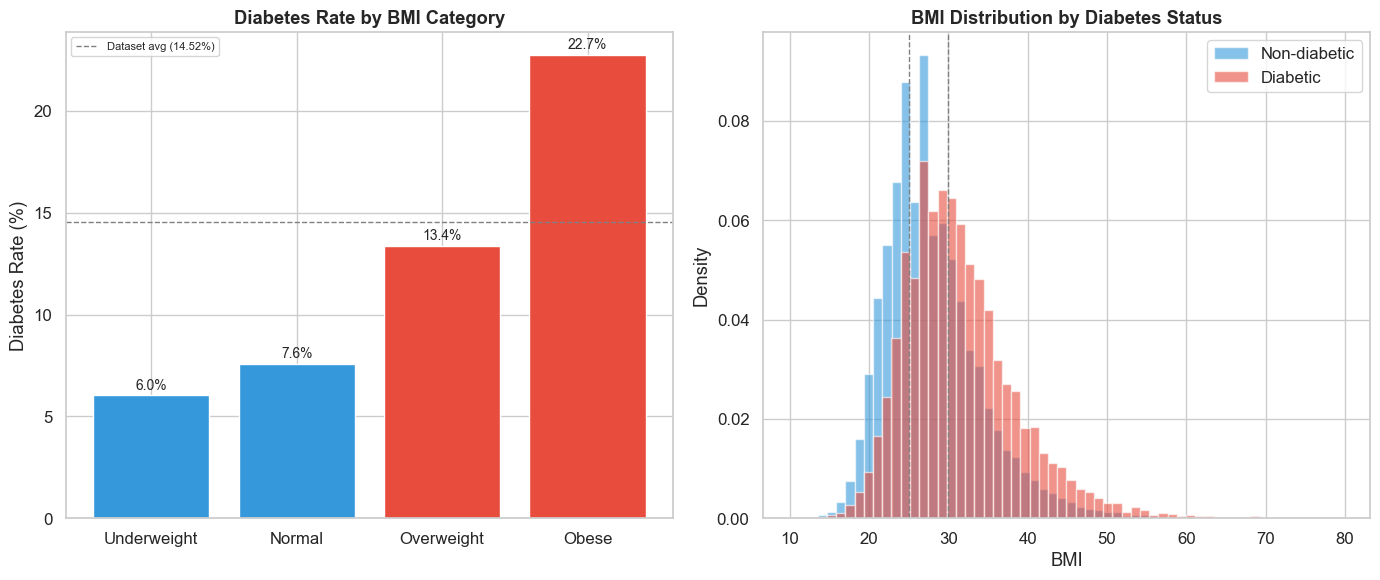

In [23]:
# --- BMI visualization ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Diabetes rate by BMI category
colors = ['#3498db', '#3498db', '#e74c3c', '#e74c3c']
bars = axes[0].bar(bmi_rates.index, bmi_rates.values, color=colors, edgecolor='white')
axes[0].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg (14.52%)')
axes[0].set_title('Diabetes Rate by BMI Category', fontweight='bold')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, bmi_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# Plot 2 — BMI distribution by diabetes status
df_bmi = df_clean[df_clean['BMI'].notna()].copy()
df_bmi['Diabetes'] = df_bmi['TARGET_DIABETES'].map({1: 'Diabetic', 0: 'Non-diabetic'})
axes[1].hist(df_bmi[df_bmi['TARGET_DIABETES']==0]['BMI'],
             bins=60, alpha=0.6, color='#3498db', label='Non-diabetic', density=True)
axes[1].hist(df_bmi[df_bmi['TARGET_DIABETES']==1]['BMI'],
             bins=60, alpha=0.6, color='#e74c3c', label='Diabetic', density=True)
axes[1].set_title('BMI Distribution by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].axvline(25, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(30, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/bmi_diabetes_rate.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — BMI

**Strong monotonic gradient:** Diabetes rate goes from 6.0% in underweight to 22.7% in obese — a 3.8x difference. BMI is one of the cleanest continuous predictors in the dataset.

**Distribution shift clearly visible:** The diabetic BMI distribution is right-shifted vs non-diabetics, with a median around BMI 30-32 vs 26-27 for non-diabetics. The overlap zone between BMI 25-35 is where the model will need to rely on additional features to discriminate.

**Business implication:** BMI above 30 should be a primary flag in any member risk scoring system. Combined with age and income, it forms the core of a simple rule-based pre-screening tool.

### Section 3.2 (continued) — Behavioral Risk Score

In [26]:
# --- Behavioral Risk Score ---
# Composite score aggregating 4 modifiable risk behaviors
# Each behavior contributes 1 point if high-risk, 0 otherwise
# Score range: 0 (no risk behaviors) to 4 (all risk behaviors)

# 1. Smoking — ever smoked 100+ cigarettes
df_clean['RISK_SMOKING'] = np.where(df_clean['SMOKE100'] == 1.0, 1, 0)

# 2. Physical inactivity — no exercise in past 30 days
df_clean['RISK_SEDENTARY'] = np.where(df_clean['EXERANY2'] == 2.0, 1, 0)

# 3. Alcohol consumption — any drinking in past 30 days
# ALCDAY4: 888 = no drinks, 777/999 already recoded to NaN
df_clean['RISK_ALCOHOL'] = np.where(
    (df_clean['ALCDAY4'].notna()) & (df_clean['ALCDAY4'] != 888.0), 1, 0
)

# 4. Obesity — BMI >= 30
df_clean['RISK_OBESE'] = np.where(df_clean['BMI'] >= 30.0, 1, 0)

# Composite behavioral risk score
risk_cols = ['RISK_SMOKING', 'RISK_SEDENTARY', 'RISK_ALCOHOL', 'RISK_OBESE']
df_clean['BEHAVIORAL_RISK_SCORE'] = df_clean[risk_cols].sum(axis=1)

print("--- Behavioral Risk Score Distribution ---")
print(df_clean['BEHAVIORAL_RISK_SCORE'].value_counts().sort_index())
print()

# Diabetes rate by score
risk_rates = df_clean.groupby('BEHAVIORAL_RISK_SCORE')['TARGET_DIABETES'].mean() * 100
print("--- Diabetes Rate by Behavioral Risk Score ---")
print(risk_rates.round(2))

--- Behavioral Risk Score Distribution ---
BEHAVIORAL_RISK_SCORE
0     88276
1    175386
2    134624
3     48049
4      6906
Name: count, dtype: int64

--- Diabetes Rate by Behavioral Risk Score ---
BEHAVIORAL_RISK_SCORE
0   10.7400
1   12.3500
2   16.5500
3   22.0900
4   25.6600
Name: TARGET_DIABETES, dtype: float64


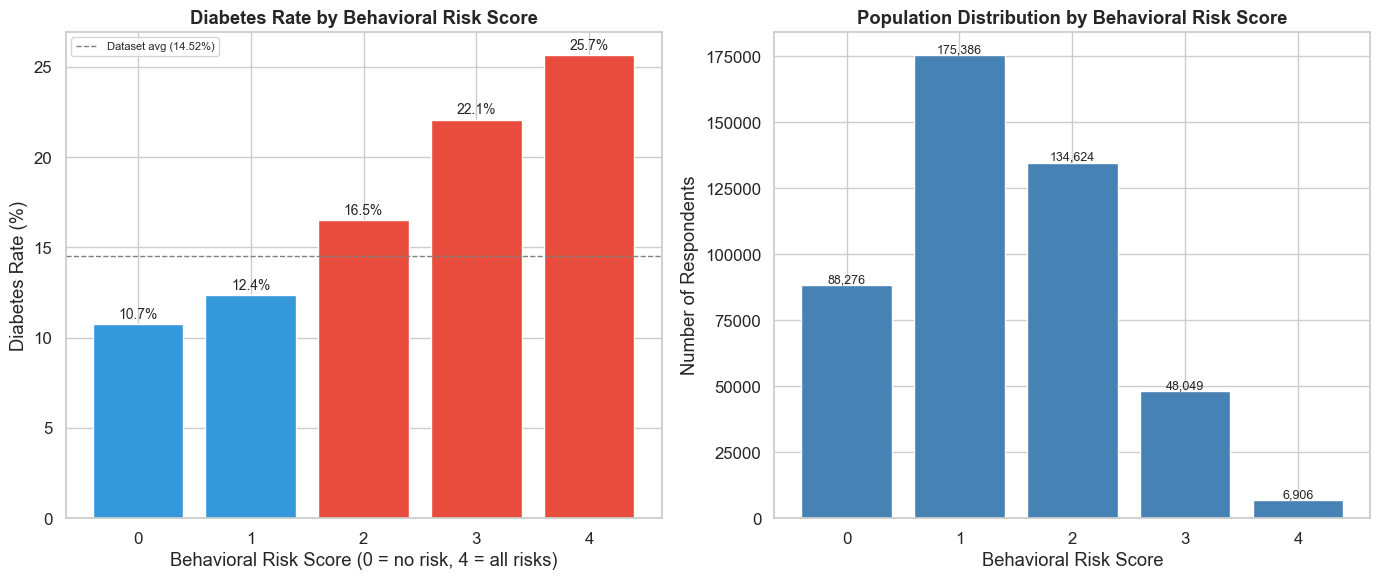

In [27]:
# --- Behavioral Risk Score visualization ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Diabetes rate by score
colors = ['#3498db' if v < 14.52 else '#e74c3c' for v in risk_rates.values]
bars = axes[0].bar(risk_rates.index.astype(str), risk_rates.values,
                   color=colors, edgecolor='white')
axes[0].axhline(14.52, color='gray', linestyle='--', linewidth=1, label='Dataset avg (14.52%)')
axes[0].set_title('Diabetes Rate by Behavioral Risk Score', fontweight='bold')
axes[0].set_xlabel('Behavioral Risk Score (0 = no risk, 4 = all risks)')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, risk_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10)

# Plot 2 — Population distribution by score
score_counts = df_clean['BEHAVIORAL_RISK_SCORE'].value_counts().sort_index()
axes[1].bar(score_counts.index.astype(str), score_counts.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('Population Distribution by Behavioral Risk Score', fontweight='bold')
axes[1].set_xlabel('Behavioral Risk Score')
axes[1].set_ylabel('Number of Respondents')
for i, val in enumerate(score_counts.values):
    axes[1].text(i, val + 1000, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/arvind.b/Documents/silent-risk-chronic-disease/reports/figures/behavioral_risk_score.png',
            dpi=150, facecolor='white')
plt.show()

#### Key Findings — Behavioral Risk Score

The composite score (smoking + sedentary + alcohol + obesity) produces a clean monotonic gradient from 10.7% at score 0 to 25.7% at score 4 — a 2.4x difference.

**Score 2 is the inflection point** — it crosses the dataset average at 16.5%. Members with 2 or more risk behaviors are above-average risk and should trigger prevention outreach.

**Population distribution:** Most respondents cluster at score 1 (175k) and 2 (135k). The 54,955 members at score 3-4 represent the highest-priority intervention target — they combine elevated risk with multiple modifiable behaviors.

**Business implication:** The behavioral risk score is a simple, explainable, and actionable pre-screening tool. It can be communicated to non-technical stakeholders without requiring model output, and serves as a baseline rule before deploying the full LightGBM scoring engine.

### Section 3.3 — Derived Variables: Multi-Morbidity Score & Under-Care Index

In [29]:
# --- 3.3 Multi-Morbidity Score ---

chronic_vars = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3',
                'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3',
                'CHCKDNY2', 'HAVARTH4']

available = [v for v in chronic_vars if v in df_clean.columns]
missing_vars = [v for v in chronic_vars if v not in df_clean.columns]
print(f"Available chronic condition variables : {len(available)}")
print(f"Missing                               : {missing_vars}")
print()

# Score = count of conditions where response = 1 (Yes diagnosed)
df_clean['MULTIMORBIDITY_SCORE'] = sum(
    (df_clean[col] == 1.0).astype(int) for col in available
)

print("--- Multi-Morbidity Score Distribution ---")
print(df_clean['MULTIMORBIDITY_SCORE'].value_counts().sort_index())
print()

# Diabetes rate by multi-morbidity score
mm_rates = df_clean.groupby('MULTIMORBIDITY_SCORE')['TARGET_DIABETES'].mean() * 100
print("--- Diabetes Rate by Multi-Morbidity Score ---")
print(mm_rates.round(2))

Available chronic condition variables : 10
Missing                               : []

--- Multi-Morbidity Score Distribution ---
MULTIMORBIDITY_SCORE
0     172223
1     131727
2      78079
3      39830
4      18915
5       7863
6       3072
7       1106
8        346
9         59
10        21
Name: count, dtype: int64

--- Diabetes Rate by Multi-Morbidity Score ---
MULTIMORBIDITY_SCORE
0     7.4500
1    12.9700
2    18.8900
3    25.1100
4    31.3400
5    38.6700
6    45.0200
7    49.5500
8    54.9100
9    55.9300
10   76.1900
Name: TARGET_DIABETES, dtype: float64


In [30]:
# --- Under-Care Index ---
# Captures members who are high-risk but under-served by healthcare system
# 3 components: no personal doctor, cost barrier, no recent checkup

# 1. No personal doctor (PERSDOC3 = 3)
df_clean['UNDERCARE_NODOC'] = np.where(df_clean['PERSDOC3'] == 3.0, 1, 0)

# 2. Could not afford doctor in past 12 months (MEDCOST1 = 1)
df_clean['UNDERCARE_COST'] = np.where(df_clean['MEDCOST1'] == 1.0, 1, 0)

# 3. No checkup in past 2+ years (CHECKUP1 = 3, 4 or 8)
df_clean['UNDERCARE_NOCHECKUP'] = np.where(
    df_clean['CHECKUP1'].isin([3.0, 4.0, 8.0]), 1, 0
)

# Under-care index: sum of 3 components (0-3)
df_clean['UNDERCARE_INDEX'] = (df_clean['UNDERCARE_NODOC'] +
                                df_clean['UNDERCARE_COST'] +
                                df_clean['UNDERCARE_NOCHECKUP'])

print("--- Under-Care Index Distribution ---")
print(df_clean['UNDERCARE_INDEX'].value_counts().sort_index())
print()

uc_rates = df_clean.groupby('UNDERCARE_INDEX')['TARGET_DIABETES'].mean() * 100
print("--- Diabetes Rate by Under-Care Index ---")
print(uc_rates.round(2))

--- Under-Care Index Distribution ---
UNDERCARE_INDEX
0    352598
1     67163
2     27313
3      6167
Name: count, dtype: int64

--- Diabetes Rate by Under-Care Index ---
UNDERCARE_INDEX
0   16.4000
1   10.0800
2    3.6300
3    3.5300
Name: TARGET_DIABETES, dtype: float64


### Section 3.3 — Key Findings

#### Multi-Morbidity Score

Extremely strong gradient from 7.5% at score 0 to 76.2% at score 10. Each additional chronic condition adds roughly 5-7 percentage points of diabetes risk. This is the most powerful derived variable in the dataset.

**Target 2 definition:** For the secondary model in Section 4.8, multi-morbidity score will be binarized as: high multi-morbidity = score >= 2 (threshold captures 43.8% of population above average risk).

#### Under-Care Index

Counter-intuitive result — diabetes rate decreases as under-care index increases (16.4% at index 0 down to 3.5% at index 3). This is a classic under-diagnosis effect: members without a doctor or recent checkup are less likely to have received a formal diabetes diagnosis, not less likely to have the disease.

**Business implication:** The under-care index does not predict diagnosed diabetes — it predicts **undetected** diabetes. Members scoring 2-3 on this index are the highest-priority targets for proactive screening outreach by the insurer. They are likely diabetic but undiagnosed.

### Section 3.4 — Geographic Aggregations

In [31]:
# --- 3.4 Geographic Aggregations ---
# State-level features to add geographic context to individual-level predictions

state_agg = df_clean.groupby('STATE').agg(
    state_diabetes_rate=('TARGET_DIABETES', 'mean'),
    state_avg_bmi=('BMI', 'mean'),
    state_avg_behavioral_risk=('BEHAVIORAL_RISK_SCORE', 'mean'),
    state_avg_multimorbidity=('MULTIMORBIDITY_SCORE', 'mean'),
    state_undercare_rate=('UNDERCARE_INDEX', lambda x: (x >= 2).mean()),
    state_no_insurance_rate=('PRIMINS2', lambda x: (x == 88.0).mean()),
    state_n=('TARGET_DIABETES', 'count')
).reset_index()

print(f"State aggregations computed: {state_agg.shape}")
print()
print(state_agg.sort_values('state_diabetes_rate', ascending=False).head(10).to_string(index=False))

# Merge back to df_clean
df_clean = df_clean.merge(state_agg, on='STATE', how='left')
print(f"\ndf_clean shape after geographic merge: {df_clean.shape}")

State aggregations computed: (53, 8)

STATE  state_diabetes_rate  state_avg_bmi  state_avg_behavioral_risk  state_avg_multimorbidity  state_undercare_rate  state_no_insurance_rate  state_n
   WV               0.2171        29.6229                     1.4836                    1.6214                0.0588                   0.0429     5753
   KY               0.2028        29.3729                     1.4017                    1.5769                0.0603                   0.0505     7383
   GU               0.1971        28.4298                     1.3354                    0.9027                0.1157                   0.0967     1634
   SC               0.1960        28.9599                     1.3481                    1.3477                0.0551                   0.0528     9382
   AL               0.1918        29.1622                     1.4137                    1.4163                0.0606                   0.0507     5047
   PR               0.1898        28.9659               

### Section 3.5 — Final Variable Selection

In [32]:
# --- 3.5 Final Variable Selection ---

# Features to keep for modeling
# Rationale: variables with clear business meaning, <30% missing, no leakage

features = [
    # Demographics
    'SEXVAR', '_AGEG5YR', 'MARITAL', 'EDUCA', 'RENTHOM1', 'VETERAN3',

    # Income & Employment
    'INCOME3', 'EMPLOY1',

    # Health status
    'GENHLTH', 'PHYSHLTH', 'MENTHLTH',

    # Healthcare access
    'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1',

    # Behavioral
    'SMOKE100', 'EXERANY2', 'ALCDAY4', 'ECIGNOW3',

    # Chronic conditions (excluding diabetes itself)
    'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3',
    'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3',
    'CHCKDNY2', 'HAVARTH4',

    # Disability
    'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON',

    # Derived features
    'BMI', 'BEHAVIORAL_RISK_SCORE', 'MULTIMORBIDITY_SCORE', 'UNDERCARE_INDEX',

    # Geographic
    'state_diabetes_rate', 'state_avg_bmi', 'state_avg_behavioral_risk',
    'state_avg_multimorbidity', 'state_undercare_rate'
]

# Keep only available features
features_available = [f for f in features if f in df_clean.columns]
features_missing = [f for f in features if f not in df_clean.columns]

print(f"Features selected  : {len(features_available)}")
print(f"Features not found : {features_missing}")

# Build final modeling dataframe
df_final = df_clean[features_available + ['TARGET_DIABETES', 'STATE']].copy()

print(f"\nFinal modeling dataframe shape: {df_final.shape}")
print(f"\nMissing rate per feature:")
missing_final = (df_final.isnull().sum() / len(df_final) * 100).sort_values(ascending=False)
print(missing_final[missing_final > 0].round(2))

Features selected  : 44
Features not found : []

Final modeling dataframe shape: (453241, 46)

Missing rate per feature:
INCOME3    44.5400
EMPLOY1    34.0600
_AGEG5YR   16.4300
BMI        10.4400
PRIMINS2   10.4300
ALCDAY4     9.5300
ECIGNOW3    7.1300
SMOKE100    6.8400
DIFFALON    4.7900
PHYSHLTH    4.5300
DECIDE      4.4500
DIFFWALK    4.4400
DIFFDRES    4.4100
BLIND       3.9100
DEAF        3.7100
MENTHLTH    3.6400
CHECKUP1    1.1500
PERSDOC3    0.9900
CVDCRHD4    0.9500
MARITAL     0.9000
RENTHOM1    0.8400
CVDINFR4    0.6400
CHCSCNC1    0.6100
VETERAN3    0.5400
ADDEPEV3    0.5300
HAVARTH4    0.5000
EDUCA       0.4900
CHCOCNC1    0.4800
CHCCOPD3    0.4200
CHCKDNY2    0.3900
ASTHMA3     0.3600
MEDCOST1    0.3500
CVDSTRK3    0.2700
GENHLTH     0.2700
EXERANY2    0.2700
dtype: float64


#### Final Feature Set — 44 Variables

| Category | Variables | Count |
|---|---|---|
| Demographics | SEXVAR, _AGEG5YR, MARITAL, EDUCA, RENTHOM1, VETERAN3 | 6 |
| Income & Employment | INCOME3, EMPLOY1 | 2 |
| Health Status | GENHLTH, PHYSHLTH, MENTHLTH | 3 |
| Healthcare Access | PRIMINS2, PERSDOC3, MEDCOST1, CHECKUP1 | 4 |
| Behavioral | SMOKE100, EXERANY2, ALCDAY4, ECIGNOW3 | 4 |
| Chronic Conditions | CVDINFR4, CVDCRHD4, CVDSTRK3, ASTHMA3, CHCSCNC1, CHCOCNC1, CHCCOPD3, ADDEPEV3, CHCKDNY2, HAVARTH4 | 10 |
| Disability | DEAF, BLIND, DECIDE, DIFFWALK, DIFFDRES, DIFFALON | 6 |
| Derived | BMI, BEHAVIORAL_RISK_SCORE, MULTIMORBIDITY_SCORE, UNDERCARE_INDEX | 4 |
| Geographic | state_diabetes_rate, state_avg_bmi, state_avg_behavioral_risk, state_avg_multimorbidity, state_undercare_rate | 5 |

**Missing data strategy:** LightGBM handles missing values natively — no imputation required. INCOME3 (44.5%) and EMPLOY1 (34.1%) are high but retained given their strong business signal demonstrated in Section 2.4.

**Leakage check:** DIABETE4 and all diabetes-derived variables excluded. MULTIMORBIDITY_SCORE includes only non-diabetes chronic conditions. No temporal leakage risk given cross-sectional survey design.